# DataCrunch Equity Market Neutral - Louis Vadet
Prediction of expected returns for the 3000 most liquid US equities.

In [1]:
%pip install crunch-cli --upgrade --quiet --progress-bar off
!crunch setup-notebook datacrunch-2 hTvDmQRRpIT0WNXPquwYYV6s


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
crunch-cli, version 11.2.0
delete /Users/louisvadet/Desktop/best submission/.crunchdao
you appear to have never submitted code before
data/moons_split.json: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/210/moons_split.json (11088 bytes)
data/y.reduced.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/210/y.reduced.parquet (7849920 bytes)
data/X.reduced.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/210/X.reduced.parquet (717782846 bytes)
                                                                                
---
Success! Your environment has been correctly setup.
Next recommended actions:
1. Load the Crunch Toolings: `crunch_tools = crunc

## Setup

In [18]:
import os 
import joblib
import pandas as pd
import crunch
import numpy as np
import lightgbm as lgb
import sklearn  # == 1.7.2
from sklearn.linear_model import Ridge, LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
plt.style.use('seaborn-v0_8-whitegrid')

In [4]:
crunch_tools = crunch.load_notebook()

loaded inline runner with module: <module '__main__'>

cli version: 11.2.0
available ram: 16.00 gb
available cpu: 8 core
----


## Explore the data

In [5]:
def get_feature_columns(X: pd.DataFrame):
    return [column for column in X.columns if column.startswith("Feature_")]

# This function just return a list of colomns in the dataframe which names start with "Feature_", 

In [6]:
# Load the data
X_train, y_train, X_test = crunch_tools.load_data()

data/moons_split.json: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/210/moons_split.json (11088 bytes)
data/moons_split.json: already exists, file length match
data/y.reduced.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/210/y.reduced.parquet (7849920 bytes)
data/y.reduced.parquet: already exists, file length match
data/X.reduced.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/210/X.reduced.parquet (717782846 bytes)
data/X.reduced.parquet: already exists, file length match


In [7]:
X_train.head()
# No leakage risk: the id changes every moon

,id,moon,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,...,Feature_1141,Feature_1142,Feature_1143,Feature_1144,Feature_1145,Feature_1146,Feature_1147,Feature_1148,Feature_1149,Feature_1150
0,1309,1,0.67,0.67,0.67,0.67,0.67,0.67,0.67,0.17,...,0.50,0.67,0.00,0.00,0.00,0.00,0.33,0.50,0.50,0.67
1,621,1,0.83,0.83,0.83,0.83,0.83,0.83,0.83,1.00,...,0.50,0.67,0.17,0.17,0.17,0.17,0.50,0.67,0.67,0.67
2,1855,1,0.83,0.83,0.83,0.83,0.83,0.83,0.83,0.33,...,0.33,0.50,0.83,0.83,0.83,0.83,1.00,0.33,0.33,0.17
3,650,1,0.83,0.83,0.83,0.83,0.83,0.83,0.83,0.83,...,0.83,0.83,0.50,0.50,0.50,0.50,0.33,0.67,0.50,0.67
4,759,1,0.83,0.83,0.83,0.83,0.83,0.83,0.83,0.67,...,0.67,0.83,0.17,0.17,0.17,0.17,0.33,0.50,0.50,0.33


Min : 1698
Max : 2624
Mean: 2100


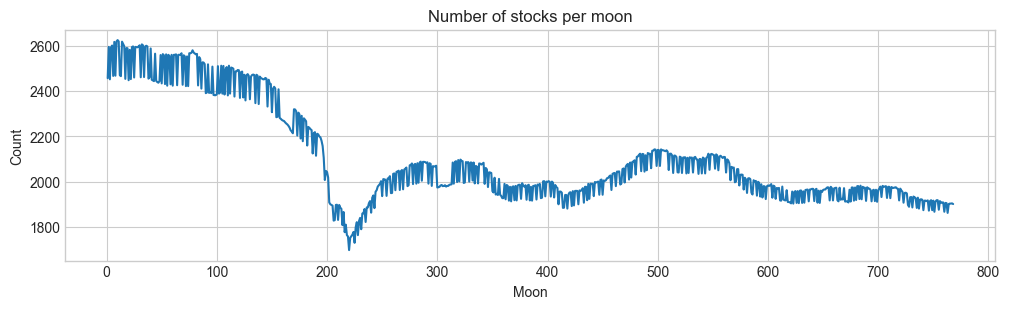

In [8]:
stocks_per_moon = X_train.groupby("moon").size()
print(f"Min : {stocks_per_moon.min()}")
print(f"Max : {stocks_per_moon.max()}")
print(f"Mean: {stocks_per_moon.mean():.0f}")

import matplotlib.pyplot as plt
stocks_per_moon.plot(figsize=(12, 3))
plt.title("Number of stocks per moon")
plt.xlabel("Moon")
plt.ylabel("Count")
plt.show()

In [9]:
feature_cols = get_feature_columns(X_train)

unique_counts = X_train[feature_cols].nunique()

print(f"Min unique values:    {unique_counts.min()}")
print(f"Max unique values:    {unique_counts.max()}")
print(f"Median unique values: {unique_counts.median()}")
print()
print("Distribution:")
print(unique_counts.value_counts().sort_index().head(20))

Min unique values:    7
Max unique values:    7
Median unique values: 7.0

Distribution:
7    1150
Name: count, dtype: int64


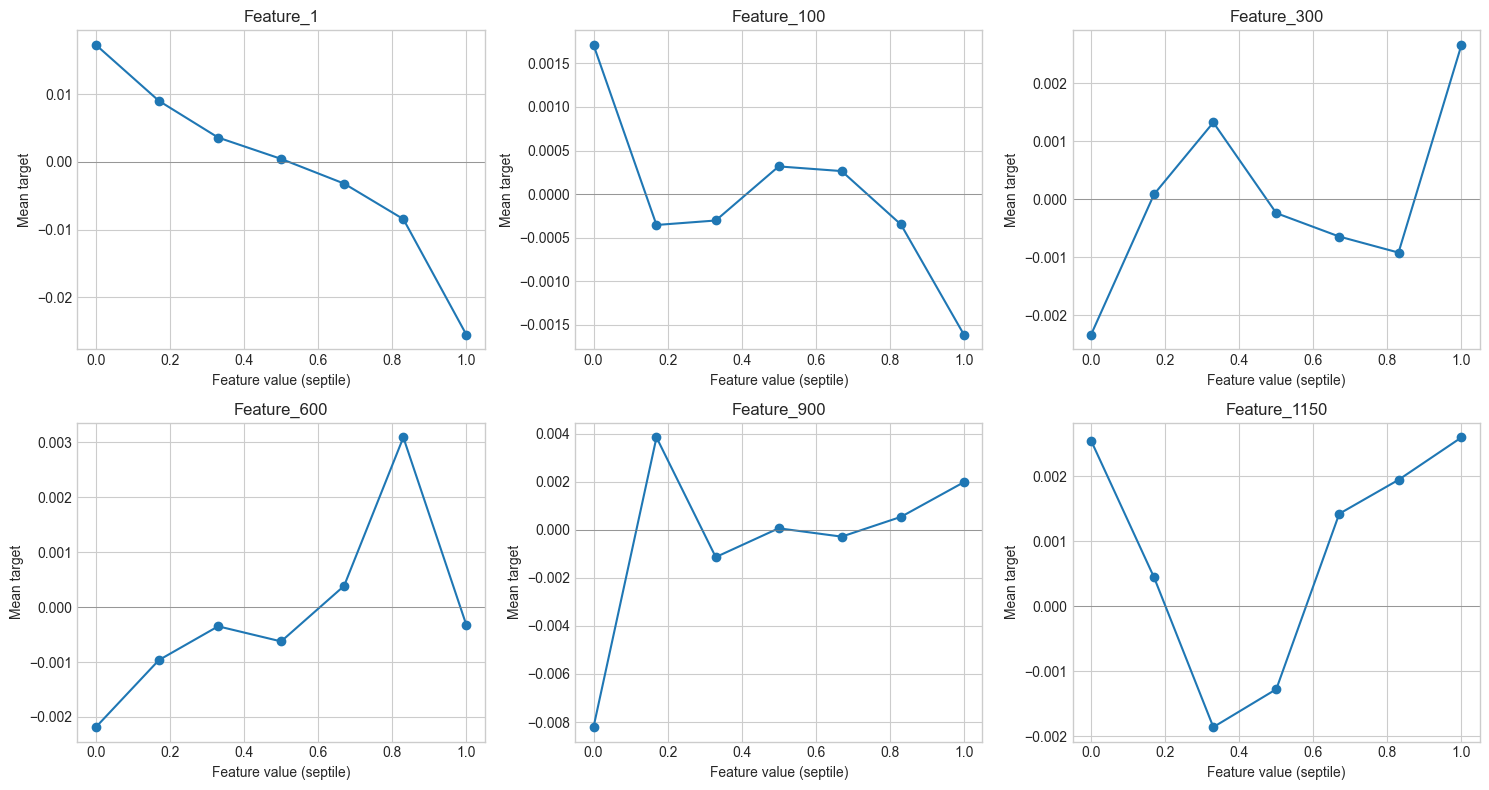

In [10]:
import matplotlib.pyplot as plt

merged_data = X_train.merge(y_train, on=["id", "moon"])

# Regarder 6 features au hasard
sample_features = ["Feature_1", "Feature_100", "Feature_300", 
                   "Feature_600", "Feature_900", "Feature_1150"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flat, sample_features):
    means = merged_data.groupby(feat)["target"].mean()
    ax.plot(means.index, means.values, marker="o")
    ax.set_title(feat)
    ax.set_xlabel("Feature value (septile)")
    ax.set_ylabel("Mean target")
    ax.axhline(0, color="grey", linewidth=0.5)
plt.tight_layout()
plt.show()


In [11]:
feature_cols = get_feature_columns(X_train)

# Confirm features are bounded in [0, 1]
print(f"Global min: {X_train[feature_cols].min().min():.2f}")
print(f"Global max: {X_train[feature_cols].max().max():.2f}")

Global min: 0.00
Global max: 1.00


In [12]:
y_train.head()

,id,moon,target
0,1309,1,0.0
1,621,1,0.0
2,1855,1,0.0
3,650,1,0.0
4,759,1,0.0


/var/folders/2_/h3gkgttd04j65y06cxywngkm0000gn/T/ipykernel_50152/2589031165.py:16: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/louisvadet/Library/Python/3.12/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


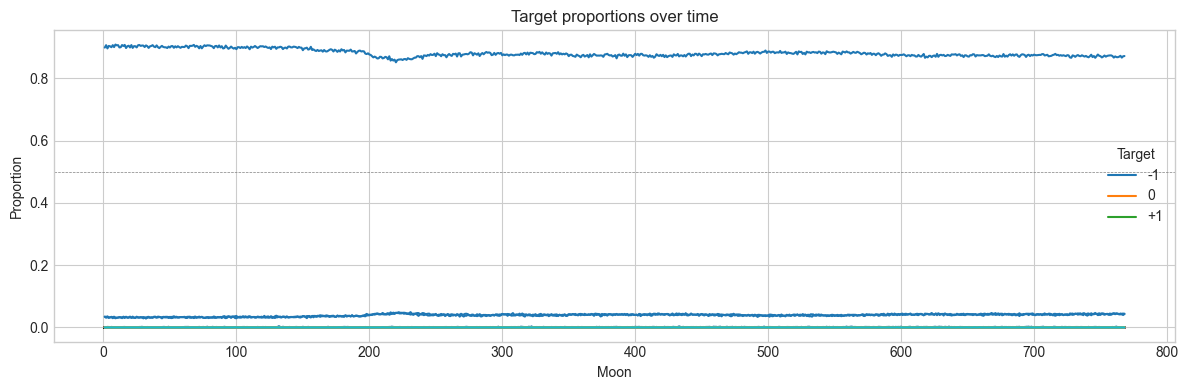

In [13]:
import matplotlib.pyplot as plt

target_props = (
    y_train.groupby("moon")["target"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 4))
target_props.plot(ax=ax)
ax.set_title("Target proportions over time")
ax.set_xlabel("Moon")
ax.set_ylabel("Proportion")
ax.legend(title="Target", labels=["-1", "0", "+1"])
ax.axhline(0.5, color="grey", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()


In [14]:
# Check for missing values
cols_with_missing = [col for col in X_train.columns if X_train[col].isnull().any()]
print(f"{len(cols_with_missing)} columns with missing values — {'imputation needed' if cols_with_missing else 'no imputation needed'}")

0 columns with missing values — no imputation needed


## Model: train and infer functions

The target is ternary: most stocks stay at **0**, a few have strong moves at **+1** or **-1**.  
A single regressor struggles with this structure, so I use a two-stage approach:

1. **LogisticRegression** : classifies each stock as "mover" (±1) or "non-mover" (0)
2. **Ridge regression** : trained only on movers, predicts the direction (+1 or -1)

Final prediction: `proba_extreme × direction`, clipped to [-1, 1]

Feature selection is done once via **Spearman correlation** between each feature and the target, across all moons.  
Spearman is preferred over Pearson here because the target is ternary (-1, 0, 1) — not normally distributed.  
It handles ties by assigning average ranks, which makes it robust to this kind of discrete target.  
The top 500 features (out of 1150) by absolute correlation are kept and saved to disk, so they can be reused in `infer()` without recomputing.



In [15]:
def train(X_train: pd.DataFrame, y_train: pd.DataFrame, model_directory_path: str) -> None:
    feature_columns = get_feature_columns(X_train)

    data = X_train[["moon", "id"] + feature_columns].merge(
        y_train[["moon", "id", "target"]], on=["moon", "id"]
    )

    model = lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=6,
        min_child_samples=2000,
        colsample_bytree=0.3,
        subsample=0.8,
        subsample_freq=1,
        reg_alpha=0.1,
        reg_lambda=0.1,
        n_jobs=-1,
        verbose=-1,
    )

    model.fit(data[feature_columns], data["target"])
    joblib.dump(model, os.path.join(model_directory_path, "model.joblib"))

    


In [16]:
def infer(X_test: pd.DataFrame, model_directory_path: str) -> pd.DataFrame:
    prediction = X_test[["id", "moon"]].copy()

    model = joblib.load(os.path.join(model_directory_path, "model.joblib"))
    feature_columns = get_feature_columns(X_test)

    prediction["prediction"] = model.predict(X_test[feature_columns]).clip(-1, 1)
    return prediction


## Local testing


In [19]:
crunch_tools.test(force_first_train=True,train_frequency=0)

11:08:00 
11:08:00 started
11:08:00 running local test
11:08:00 internet access isn't restricted, no check will be done
11:08:00 
11:08:01 looping moon=773 train=True (1/9)
11:08:01 executing - command=train


data/moons_split.json: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/210/moons_split.json (11088 bytes)
data/moons_split.json: already exists, file length match
data/y.reduced.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/210/y.reduced.parquet (7849920 bytes)
data/y.reduced.parquet: already exists, file length match
data/X.reduced.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/210/X.reduced.parquet (717782846 bytes)
data/X.reduced.parquet: already exists, file length match


11:20:26 executing - command=infer
11:20:30 looping moon=774 train=False (2/9)
11:20:30 executing - command=infer
11:20:32 looping moon=775 train=False (3/9)
11:20:32 executing - command=infer
11:20:36 looping moon=776 train=False (4/9)
11:20:36 executing - command=infer
11:20:39 looping moon=777 train=False (5/9)
11:20:39 executing - command=infer
11:20:42 looping moon=778 train=False (6/9)
11:20:42 executing - command=infer
11:20:45 looping moon=779 train=False (7/9)
11:20:45 executing - command=infer
11:20:48 looping moon=780 train=False (8/9)
11:20:48 executing - command=infer
11:20:50 looping moon=781 train=False (9/9)
11:20:50 executing - command=infer
11:20:53 save prediction - path=prediction
11:20:53 determinism check: passed
11:20:53 ended
11:20:53 duration - time=00:12:52
11:20:53 memory - before="94.62 MB" after="2.38 GB" consumed="2.28 GB"


## Results

In [20]:
prediction = pd.read_parquet("prediction/prediction.parquet") 
prediction

,id,moon,prediction
0,1621514,773,-0.018067
1,1620399,773,0.009188
2,1622126,773,0.019667
3,1621963,773,0.009066
4,1620703,773,-0.000346
...,...,...,...
16983,1636502,781,-0.001137
16984,1636666,781,0.003341
16985,1636232,781,-0.003102
16986,1636831,781,-0.002587


## Local scoring

In [21]:
# Load the targets
y_test = pd.read_parquet("data/y.reduced.parquet",filters=[("moon", "in", prediction["moon"].unique())])
y_test 

,id,moon,target
0,1621514,773,0.0
1,1620399,773,0.0
2,1622126,773,0.0
3,1621963,773,-1.0
4,1620703,773,0.0
...,...,...,...
16983,1636502,781,0.0
16984,1636666,781,0.0
16985,1636232,781,0.0
16986,1636831,781,0.0


In [22]:
# Define the scoring function (la corrélation de Pearson utilisée par CrunchDAO)
def score(group: pd.DataFrame):
    return group["prediction"].corr(group["target"], method="pearson")




# Merge the prediction with the target y (with moon and id)
merged = y_test.merge(prediction,on=["moon", "id"])

# Compute the pearson for each moon
pearson_values = merged.groupby("moon").apply(score, include_groups=False).fillna(0) 

print(pearson_values) # voir si certains moons sont très différents des autres
print(pearson_values.mean())

moon
773    0.091133
774    0.017523
775    0.005513
776    0.007213
777    0.007227
778    0.052382
779    0.058072
780    0.042633
781    0.036563
dtype: float64
0.03536215151453362


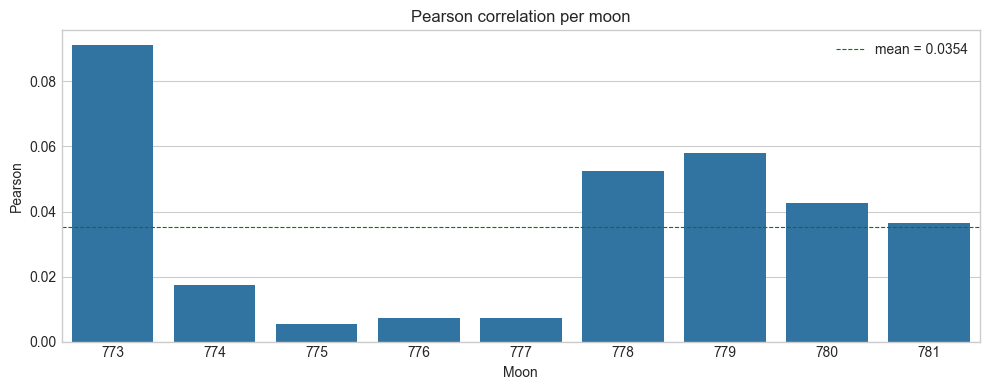

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=pearson_values.index, y=pearson_values.values, ax=ax)
ax.axhline(pearson_values.mean(), color="green", linewidth=0.8, linestyle="--", label=f"mean = {pearson_values.mean():.4f}")
ax.set_title("Pearson correlation per moon")
ax.set_xlabel("Moon")
ax.set_ylabel("Pearson")
ax.legend()
plt.tight_layout()
plt.show()


In [24]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

model = joblib.load("resources/model.joblib")
feature_columns = get_feature_columns(X_train)

# Two importance metrics: 'gain' = quality of splits, 'split' = number of times used
importance_gain = pd.Series(
    model.booster_.feature_importance(importance_type="gain"),
    index=feature_columns,
).sort_values(ascending=False)

importance_split = pd.Series(
    model.booster_.feature_importance(importance_type="split"),
    index=feature_columns,
).sort_values(ascending=False)

# 1. How many features are actually used?
n_used = (importance_gain > 0).sum()
print(f"Features actually used by the model: {n_used} / {len(feature_columns)}")
print(f"Features completely ignored:        {len(feature_columns) - n_used}")


Features actually used by the model: 1145 / 1150
Features completely ignored:        5


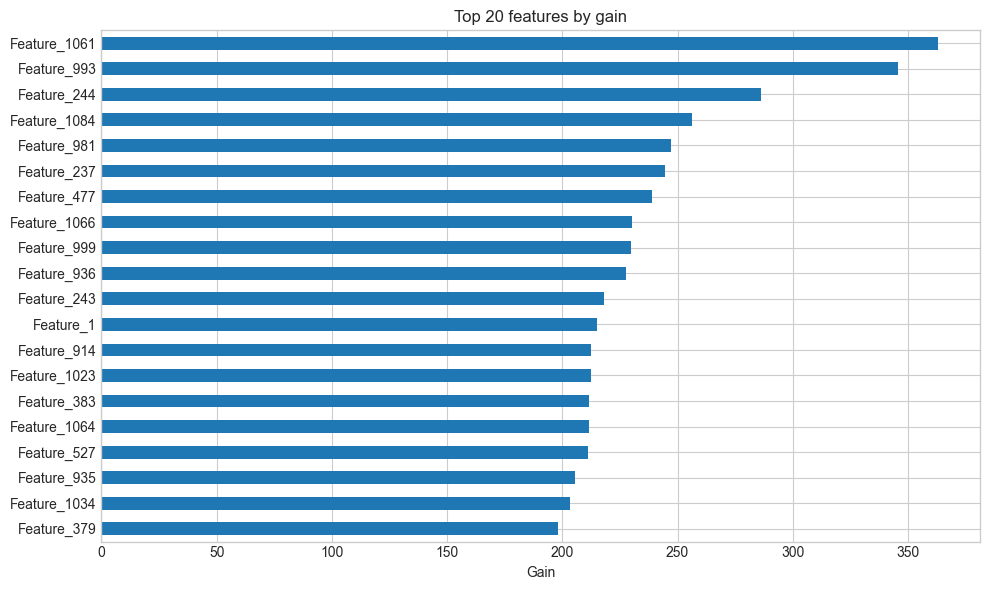

In [25]:
# 2. Top 20 features by gain
top20 = importance_gain.head(20)
fig, ax = plt.subplots(figsize=(10, 6))
top20[::-1].plot(kind="barh", ax=ax)
ax.set_title("Top 20 features by gain")
ax.set_xlabel("Gain")
plt.tight_layout()
plt.show()


Features needed for 50% of total gain: 297
Features needed for 80% of total gain: 600
Features needed for 90% of total gain: 749
Features needed for 95% of total gain: 856


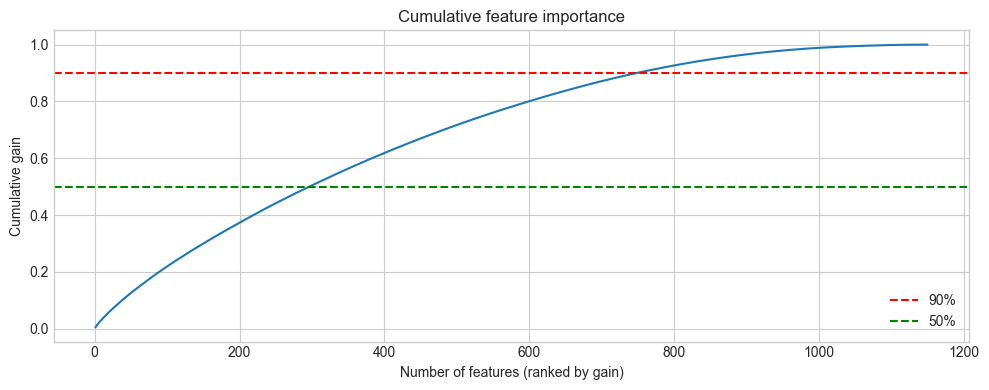

In [26]:
# 3. Cumulative importance — how many features capture 90% of the signal?
cumulative = importance_gain.cumsum() / importance_gain.sum()

n_50 = (cumulative <= 0.50).sum() + 1
n_80 = (cumulative <= 0.80).sum() + 1
n_90 = (cumulative <= 0.90).sum() + 1
n_95 = (cumulative <= 0.95).sum() + 1

print(f"Features needed for 50% of total gain: {n_50}")
print(f"Features needed for 80% of total gain: {n_80}")
print(f"Features needed for 90% of total gain: {n_90}")
print(f"Features needed for 95% of total gain: {n_95}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(cumulative) + 1), cumulative.values)
ax.axhline(0.9, color="red", linestyle="--", label="90%")
ax.axhline(0.5, color="green", linestyle="--", label="50%")
ax.set_xlabel("Number of features (ranked by gain)")
ax.set_ylabel("Cumulative gain")
ax.set_title("Cumulative feature importance")
ax.legend()
plt.tight_layout()
plt.show()


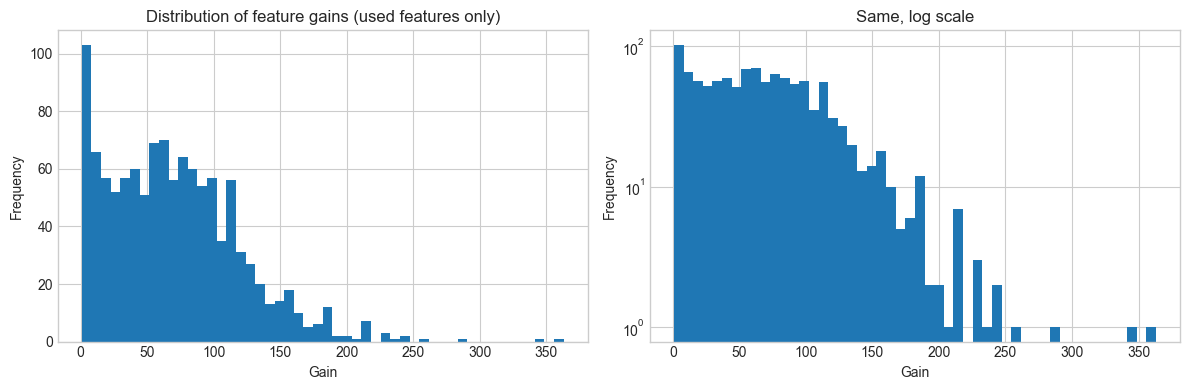

In [27]:
# 4. Distribution of importance — are a few features dominant or is it spread out?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
importance_gain[importance_gain > 0].plot(kind="hist", bins=50, ax=axes[0])
axes[0].set_title("Distribution of feature gains (used features only)")
axes[0].set_xlabel("Gain")

importance_gain[importance_gain > 0].apply(lambda x: max(x, 1e-6)).plot(
    kind="hist", bins=50, ax=axes[1], log=True
)
axes[1].set_title("Same, log scale")
axes[1].set_xlabel("Gain")
plt.tight_layout()
plt.show()


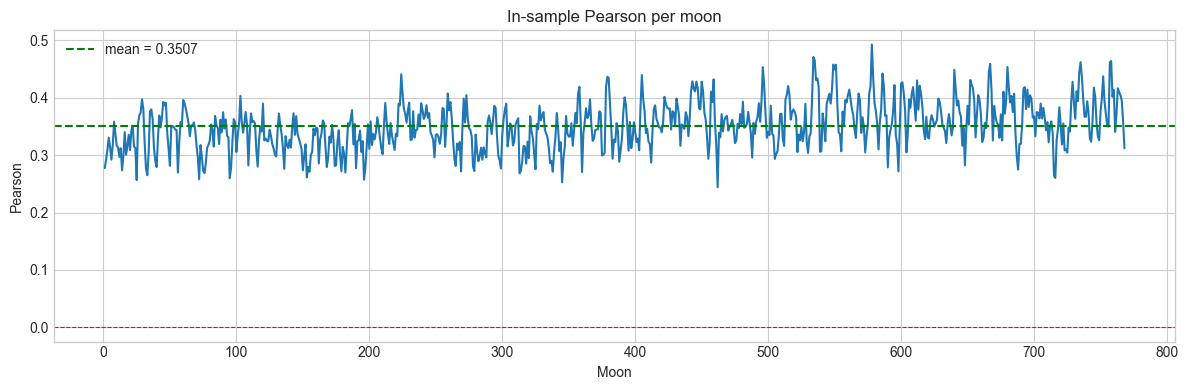

In [28]:
# 5. Performance per moon — does the model work on all moons or just some?
pred_train = X_train[["id", "moon"]].copy()
pred_train["prediction"] = model.predict(X_train[feature_columns]).clip(-1, 1)
merged_train = y_train.merge(pred_train, on=["id", "moon"])

pearson_per_moon = merged_train.groupby("moon").apply(
    lambda g: g["prediction"].corr(g["target"]), include_groups=False
).fillna(0)

fig, ax = plt.subplots(figsize=(12, 4))
pearson_per_moon.plot(ax=ax)
ax.axhline(0, color="red", linestyle="--", linewidth=0.8)
ax.axhline(pearson_per_moon.mean(), color="green", linestyle="--",
           label=f"mean = {pearson_per_moon.mean():.4f}")
ax.set_title("In-sample Pearson per moon")
ax.set_xlabel("Moon")
ax.set_ylabel("Pearson")
ax.legend()
plt.tight_layout()
plt.show()
